# **UCI-HAR - CBAM (PyTorch)**
- CBAM(Channel and Spatial Attention Module)은 CNN에서 성능을 향상시키기 위해 제안된 어텐션 모듈이다.
- 입력 피처 맵에서 중요한 정보를 강조하고 덜 중요한 정보를 억제함으로써, 모델이 더 중요한 특성에 집중할 수 있도록 도움을 준다.
- Channel Attention과 Spatial Attention의 두 가지 어텐션 메커니즘을 결합한 구조

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch 관련 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPU 가속 공식 설정 (Colab 환경 대응)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data load

In [3]:
TRAIN = "train/"
TEST = "test/"

# 구글 드라이브 연동 경로 유지
DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [4]:
# UCI HAR 데이터셋 상수 설정
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [5]:
# 1. X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)

    # 파이토치:   (1, 0, 2) -> (샘플 수, 특성 수, 타임스텝 수)
    return np.transpose(X_signals, (1, 0, 2))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("=== X Data Shape (PyTorch Style) ===")
print("X_train shape (Batch, Channels, Timesteps):", X_train.shape) # (7352, 9, 128)
print("X_test shape (Batch, Channels, Timesteps):", X_test.shape)   # (2947, 9, 128)

=== X Data Shape (PyTorch Style) ===
X_train shape (Batch, Channels, Timesteps): (7352, 9, 128)
X_test shape (Batch, Channels, Timesteps): (2947, 9, 128)


In [6]:
# 2. y 데이터 로드 함수 (정수형 레이블 그대로 유지)
def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 파이토치 CrossEntropyLoss는 target으로 Long(int64) 타입을 요구하므로 np.int64로 설정
    return np.array(labels, dtype=np.int64) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("\n=== y Data Shape ===")
print("y_train shape (정수 인덱스):", y_train.shape) # (7352,)
print("y_test shape (정수 인덱스):", y_test.shape)   # (2947,)
print("y_train 앞 5개 샘플:", y_train[:5])


=== y Data Shape ===
y_train shape (정수 인덱스): (7352,)
y_test shape (정수 인덱스): (2947,)
y_train 앞 5개 샘플: [4 4 4 4 4]


# Model building

- CBAM (Convolutional Block Attention Module) 구조를 1D CNN에 맞춰 적용
  - Channel Attention Module : 먼저 입력 피처 맵에 대해 채널별로 중요한 정보를 학습하고, 채널별로 가중치를 적용
  - Spatial Attention Module : 채널 어텐션이 적용된 피처 맵에 대해 공간적으로 중요한 영역을 학습하여 위치별로 다른 가중치를 적용
  - Global Average Pooling(정보를 압축) + Global Max Pooling(가장 의미 있는 정보 추출)

CBAM block

In [34]:
class CBAMBlock(nn.Module):
    def __init__(self, channels, reduction_ratio=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.shared_mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(channels // reduction_ratio, channels)
        )
        self.sigmoid = nn.Sigmoid()
        self.spatial_conv = nn.Conv1d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2)

    def forward(self, x):
        batch, channels, length = x.size()
        avg_pool = F.adaptive_avg_pool1d(x, 1).view(batch, channels)
        max_pool = F.adaptive_max_pool1d(x, 1).view(batch, channels)
        channel_attention = self.sigmoid(self.shared_mlp(avg_pool) + self.shared_mlp(max_pool)).unsqueeze(-1)
        scale_channel = x * channel_attention

        spatial_avg = torch.mean(scale_channel, dim=1, keepdim=True)
        spatial_max = torch.max(scale_channel, dim=1, keepdim=True)[0]
        spatial_attention = self.sigmoid(self.spatial_conv(torch.cat([spatial_avg, spatial_max], dim=1)))

        return scale_channel * spatial_attention

Classifier Model Building

In [35]:
class CBAMModel(nn.Module):
    def __init__(self, input_channels=9, num_classes=6):
        super(CBAMModel, self).__init__()

        # 첫 번째 Conv 레이어가 9개의 입력 채널을 받아 128개의 특징 피처맵을 생성
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            CBAMBlock(channels=128, reduction_ratio=16)
        )

        self.block2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            CBAMBlock(channels=256, reduction_ratio=16),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )

        self.block3 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            CBAMBlock(channels=256, reduction_ratio=16)
        )

        self.block4 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            CBAMBlock(channels=256, reduction_ratio=16),
            nn.MaxPool1d(kernel_size=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = F.adaptive_avg_pool1d(x, 1).view(x.size(0), -1)
        output = self.fc(x)
        return output

Model 생성 및 확인

In [43]:
if __name__ == "__main__":
    # GPU 사용 가능 여부 확인
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 모델 생성 (클래스명을 CBAMModel로 매핑, 입력 채널은 원래 센서 축 개수인 9)
    model = CBAMModel(input_channels=9, num_classes=6).to(device)
    print(model)

    # 2. 더미 데이터 생성
    # 실제 데이터로더(train_loader)에서 나오는 차원 순서와 똑같이 생성
    # (Batch=16, Channel=9, Seq_len=128)
    dummy_x = torch.randn(16, 9, 128).to(device)

    # 3. 예측 수행
    dummy_out = model(dummy_x)
    print("\n" + "="*40)
    print(f"입력 데이터 형태: {dummy_x.shape}")      # torch.Size([16, 9, 128])
    print(f"출력 데이터 형태: {dummy_out.shape}")    # torch.Size([16, 6])
    print("="*40)

CBAMModel(
  (block1): Sequential(
    (0): Conv1d(9, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): CBAMBlock(
      (shared_mlp): Sequential(
        (0): Linear(in_features=128, out_features=8, bias=True)
        (1): ReLU()
        (2): Linear(in_features=8, out_features=128, bias=True)
      )
      (sigmoid): Sigmoid()
      (spatial_conv): Conv1d(2, 1, kernel_size=(7,), stride=(1,), padding=(3,))
    )
  )
  (block2): Sequential(
    (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): CBAMBlock(
      (shared_mlp): Sequential(
        (0): Linear(in_features=256, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=256, bias=True)
      )
      (sigmoid): Sigmoid()
      (spatial_conv): Conv1

# Loss + Callback

In [44]:
import copy
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. 손실함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()                     # categorical_crossentropy + Softmax 역할
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 기본 lr=0.001 시작

# 2. ReduceLROnPlateau 스케줄러 정의 (Keras와 동일한 세팅)
lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',          # val_loss 최소화를 목표로 설정
    factor=0.2,          # Keras의 factor=0.2
    patience=8,          # Keras의 patience=8
    min_lr=0.00001,      # Keras의 min_lr
)

# 3. ModelCheckpoint 및 EarlyStopping을 수동 제어하기 위한 기준 변수 설정
early_stopping_patience = 25
patience_counter = 0

best_val_acc = 0.0                                 # Keras의 mode='max' (val_categorical_accuracy 기준)
best_model_wts = copy.deepcopy(model.state_dict()) # restore_best_weights=True를 위한 가중치 저장소

checkpoint_path = "UCI_HAR_CBAM_best.pt"

# Model train

In [45]:
import time
from torch.utils.data import TensorDataset, random_split

# --- 1. Dataset 및 DataLoader 준비 (Keras의 validation_split=0.2 및 batch_size=16 대응) ---
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)  # 원-핫 인코딩 대신 정수형 레이블 사용

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [46]:
# --- 2. History 저장을 위한 딕셔너리 정의 ---
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

In [47]:
# --- 3. 학습 및 검증 루프 실행 (epochs=100) ---
epochs = 100

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # [Train Phase]
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        optimizer.step()

        # 통계 계산
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # [Validation Phase]
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 검증 시에는 그래디언트 계산 제외 (메모리 절약)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에포크 결과 출력
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --- 4. Callbacks 수동 연동 단계 ---
    # (1) ReduceLROnPlateau 스케줄러 업데이트
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"Epoch {epoch}: val_categorical_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping triggered. Restoring model weights from the end of the best epoch.")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

Epoch 1/100 - 4.7s - loss: 0.3343 - accuracy: 0.8810 - val_loss: 0.1586 - val_accuracy: 0.9477 - lr: 0.001000
Epoch 1: val_categorical_accuracy improved to 0.94765, saving model to UCI_HAR_CBAM_best.pt
Epoch 2/100 - 5.1s - loss: 0.1862 - accuracy: 0.9293 - val_loss: 0.1324 - val_accuracy: 0.9449 - lr: 0.001000
Epoch 3/100 - 4.6s - loss: 0.1889 - accuracy: 0.9276 - val_loss: 0.1257 - val_accuracy: 0.9517 - lr: 0.001000
Epoch 3: val_categorical_accuracy improved to 0.95173, saving model to UCI_HAR_CBAM_best.pt
Epoch 4/100 - 6.8s - loss: 0.1672 - accuracy: 0.9357 - val_loss: 0.1207 - val_accuracy: 0.9402 - lr: 0.001000
Epoch 5/100 - 5.1s - loss: 0.1552 - accuracy: 0.9359 - val_loss: 0.1290 - val_accuracy: 0.9456 - lr: 0.001000
Epoch 6/100 - 4.3s - loss: 0.1724 - accuracy: 0.9352 - val_loss: 0.1198 - val_accuracy: 0.9422 - lr: 0.001000
Epoch 7/100 - 5.3s - loss: 0.1501 - accuracy: 0.9373 - val_loss: 0.1183 - val_accuracy: 0.9531 - lr: 0.001000
Epoch 7: val_categorical_accuracy improved to 

# Evaluation

Best 기록 확인

In [49]:
# --- 1. 가중치를 불러올 빈 모델 객체 생성 ---
best_model = CBAMModel(input_channels=9, num_classes=6).to(device)

# 가중치 파일(.pt) 로드
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Successfully loaded best model weights from {checkpoint_path}")


# --- 2. 데이터 평가를 위한 수동 함수 정의 ---
def evaluate_pytorch_model(model, X_data, y_data, batch_size=16):
    # 케라스의 evaluate(verbose=0)처럼 배치를 돌며 손실과 정확도를 누적 계산
    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 평가용 DataLoader 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# --- 3. Training & Test 데이터셋 평가 및 출력 ---
# X_train전체 데이터에 대해 평가 (Keras의 validation_split 전 원본 데이터 기준)
train_loss, train_acc = evaluate_pytorch_model(best_model, X_train, y_train)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

# X_test 데이터셋 평가
test_loss, test_acc = evaluate_pytorch_model(best_model, X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Successfully loaded best model weights from UCI_HAR_CBAM_best.pt
Training accuracy: 99.90%
Training loss: 0.0037
Test accuracy: 95.69%
Test loss: 0.1624


Classification Report

In [50]:
# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성 (X_test 전체를 안정적으로 처리하기 위해 배치 단위 구동)
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        batch_X = batch_X[0].to(device) # TensorDataset은 튜플 형태로 반환하므로 꺼내옴

        # 순전파로 로짓(Logit) 계산
        outputs = best_model(batch_X)

        # 로짓을 소프트맥스를 통해 확률값(0~1 사이)으로 변환
        probabilities = F.softmax(outputs, dim=1)

        # 가장 높은 확률을 가진 클래스 추출
        _, predicted = torch.max(probabilities, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# --- 2. 분류 리포트 출력 ---
print("\nClassification Report:")
# y_test는 이미 정수형 레이블(0~5)이므로 그대로 사용
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9577    0.9784       496
           1     0.9956    0.9639    0.9795       471
           2     0.9372    0.9952    0.9654       420
           3     0.9500    0.8513    0.8980       491
           4     0.8885    0.9737    0.9291       532
           5     0.9817    1.0000    0.9908       537

    accuracy                         0.9569      2947
   macro avg     0.9588    0.9570    0.9569      2947
weighted avg     0.9586    0.9569    0.9567      2947



Loss / Accuracy 그래프

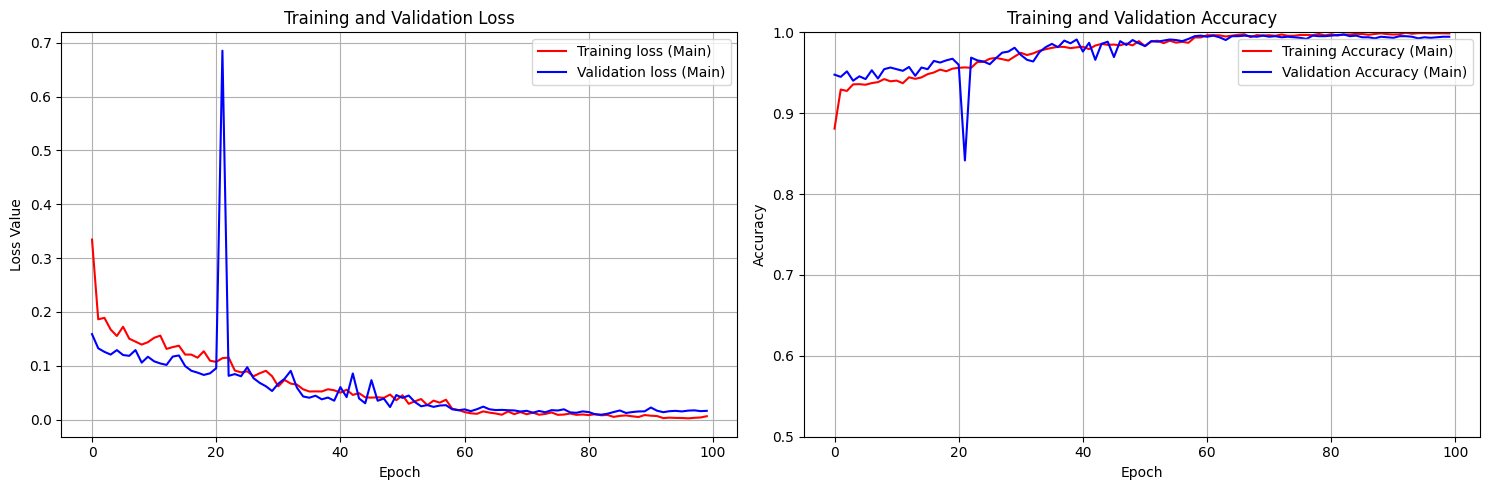

In [51]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
# 파이토치 루프에서 직접 채워넣은 history 딕셔너리를 활용
train_loss = history['loss']
train_accuracy = history['accuracy']
val_loss = history['val_loss']
val_accuracy = history['val_accuracy']

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0]) # 데이터셋 특성에 맞춰 Y축 범위 지정
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Embedding t-SNE

입력 공간 형태 (Flattened): (1471, 1152)
잠재 공간 형태: (1471, 256)
입력 공간 t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


잠재 공간 t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


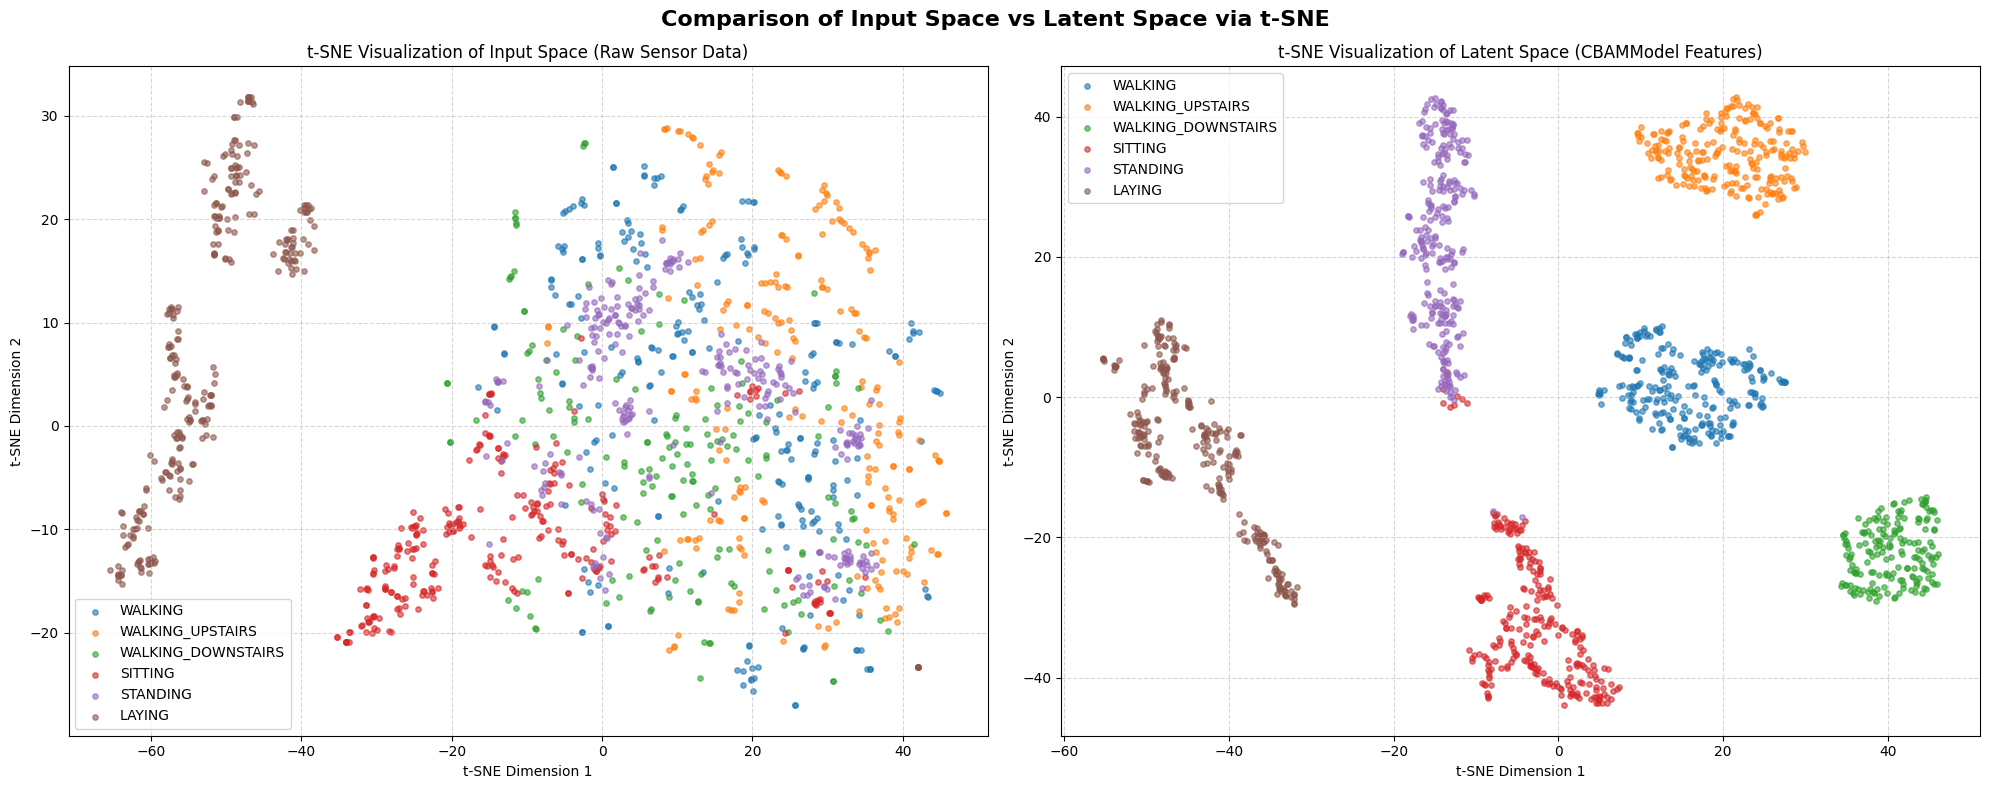

In [56]:
from sklearn.manifold import TSNE

def visualize_dual_tsne(model, data_loader, device):
    model.eval()

    input_features = []
    latent_embeddings = []
    labels = []

    # 1. 입력 데이터, 잠재공간 임베딩 벡터 및 라벨 추출
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            # 1-1. 입력 공간 데이터 수집 (Shape: [Batch, Channel, Length])
            # t-SNE 연산을 위해 배치 제외 나머지를 1차원 벡터로 평탄화 (Shape: [Batch, Channel * Length])
            inputs_flatten = batch_X.view(batch_X.size(0), -1).cpu().numpy()
            input_features.append(inputs_flatten)

            # 1-2. 잠재 공간 임베딩 수집
            batch_X = batch_X.to(device)
            x = model.block1(batch_X)
            x = model.block2(x)
            x = model.block3(x)
            x = model.block4(x)

            # Global Average Pooling 1D 수행 (Shape: [Batch, 256])
            latent_vector = torch.nn.functional.adaptive_avg_pool1d(x, 1).view(x.size(0), -1)
            latent_embeddings.append(latent_vector.cpu().numpy())

            # 1-3. 라벨 처리 (원-핫 인코딩 대응 안전장치)
            if len(batch_y.shape) > 1 and batch_y.shape[1] > 1:
                labels.append(torch.argmax(batch_y, dim=1).cpu().numpy())
            else:
                labels.append(batch_y.cpu().numpy())

    # 리스트에 담긴 배치 데이터를 하나로 결합
    input_features = np.concatenate(input_features, axis=0)
    latent_embeddings = np.concatenate(latent_embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)

    print(f"입력 공간 형태 (Flattened): {input_features.shape}")   # (전체 데이터 개수, 9 * 128)
    print(f"잠재 공간 형태: {latent_embeddings.shape}")            # (전체 데이터 개수, 256)

    # 2. t-SNE를 이용한 차원 축소 (각각 2차원으로 축소)
    print("입력 공간 t-SNE 차원 축소 진행 중...")
    tsne_input = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_input_results = tsne_input.fit_transform(input_features)

    print("잠재 공간 t-SNE 차원 축소 진행 중...")
    tsne_latent = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_latent_results = tsne_latent.fit_transform(latent_embeddings)

    # 3. Matplotlib 1x2 서브플롯 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # UCI HAR 클래스 네임
    class_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
    num_classes = len(class_names)

    # 두 그래프 모두에 클래스별 데이터 플롯
    for i in range(num_classes):
        indices = np.where(labels == i)

        # [왼쪽] 입력 공간 시각화
        ax1.scatter(
            tsne_input_results[indices, 0],
            tsne_input_results[indices, 1],
            label=class_names[i],
            alpha=0.6,
            s=15
        )

        # [오른쪽] 잠재 공간 시각화
        ax2.scatter(
            tsne_latent_results[indices, 0],
            tsne_latent_results[indices, 1],
            label=class_names[i],
            alpha=0.6,
            s=15
        )

    # 왼쪽 Plot(입력 공간) 스타일링
    ax1.set_title('t-SNE Visualization of Input Space (Raw Sensor Data)')
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='best')

    # 오른쪽 Plot(잠재 공간) 스타일링
    ax2.set_title('t-SNE Visualization of Latent Space (CBAMModel Features)')
    ax2.set_xlabel('t-SNE Dimension 1')
    ax2.set_ylabel('t-SNE Dimension 2')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='best')

    plt.suptitle('Comparison of Input Space vs Latent Space via t-SNE', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- 시각화 함수 호출 ---
visualize_dual_tsne(model, val_loader, device)

혼동 행렬 (Confusion Matrix)

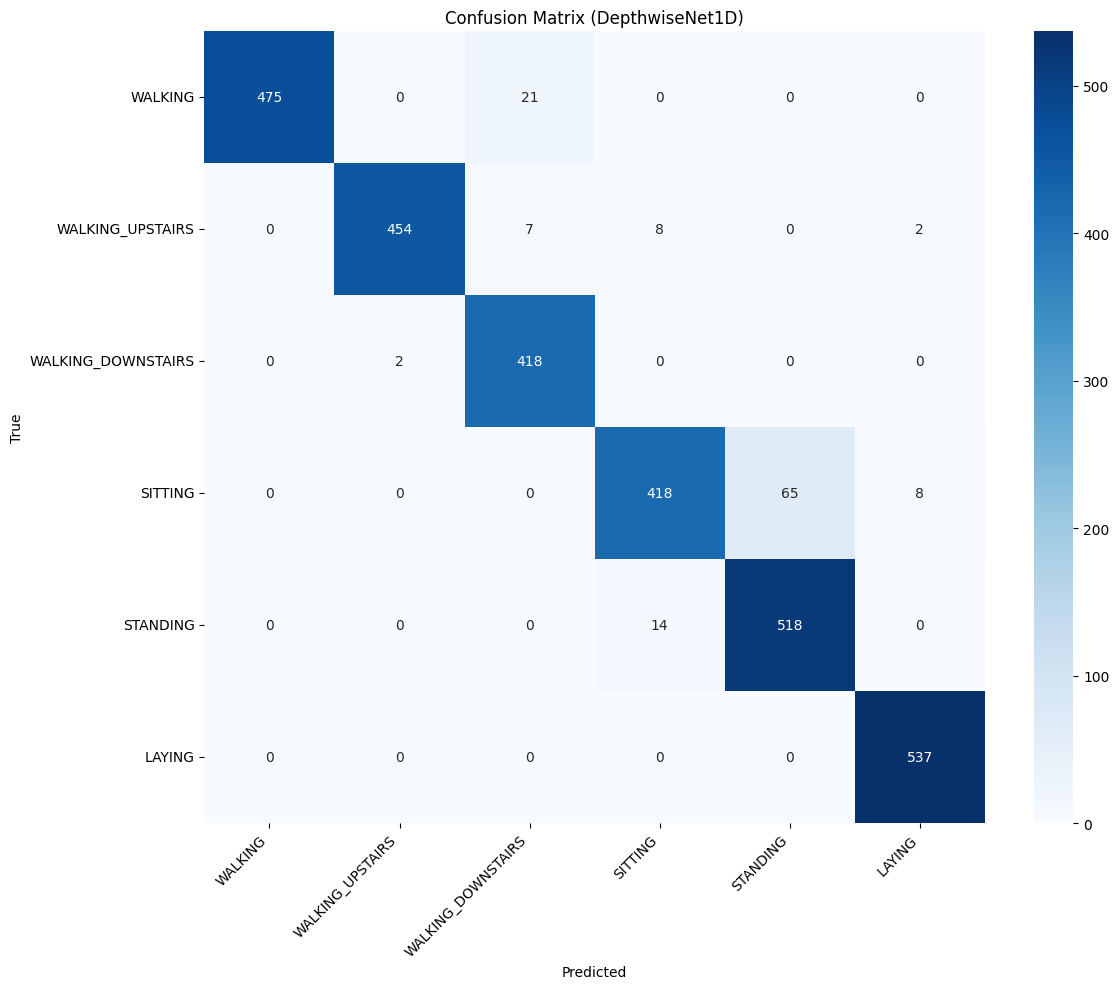

In [53]:
# --- 1. 혼동 행렬(Confusion Matrix) 계산 ---
cm = confusion_matrix(y_test, y_pred)

# --- 2. Seaborn Heatmap을 이용한 시각화 ---
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (DepthwiseNet1D)')

# 클래스 개수에 맞게 축 레이블(WALKING, SITTING 등) 설정
n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()